<a href="https://colab.research.google.com/github/VyshnaviKanchi/Uber-Fare-Prediction/blob/main/UberFarePorediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [22]:
from google.colab import files
uploded = files.upload()

Saving uber.csv to uber (1).csv


In [69]:
df = pd.read_csv("uber.csv")
df = pd.DataFrame(df)
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [70]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [71]:
df.isna().sum()

,0
Unnamed: 0,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,1
dropoff_latitude,1
passenger_count,0


In [72]:
df = df.dropna()
df.isna().sum()

,0
Unnamed: 0,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
passenger_count,0


In [73]:
df.drop(['Unnamed: 0', 'key'], axis=1, inplace=True, errors='ignore')

In [74]:
df.dtypes

,0
fare_amount,float64
pickup_datetime,object
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
passenger_count,int64


In [75]:
#Remove extream outlayers
df = df[(df.fare_amount > 0) & (df.fare_amount < 450)]

# Filter to keep points roughly within the NYC area
# (Lat: 40 to 42, Lon: -75 to -72)
df = df[(df.pickup_longitude.between(-75, -72)) &
        (df.pickup_latitude.between(40, 42))]
df = df[(df.dropoff_longitude.between(-75, -72)) &
        (df.dropoff_latitude.between(40, 42))]

# Remove unrealistic numbers of pasengers
df = df[(df.passenger_count >= 0) & (df.passenger_count <= 8)]

In [76]:
df.shape

(195785, 7)

In [77]:
import numpy as np

# A. Calculate Haversine Distance
def haversine_distance(lon1, lat1, lon2, lat2):
    # Convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c # Radius of earth in kilometers
    return km

df['distance_km'] = haversine_distance(df['pickup_longitude'], df['pickup_latitude'],
                                       df['dropoff_longitude'], df['dropoff_latitude'])

# B. Process Date and Time
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.dayofweek
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year

# Now drop the original datetime column as it's no longer needed for the math
df.drop('pickup_datetime', axis=1, inplace=True)

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [79]:
# 1. Define Features (X) and Target (y)
# We include the coordinates, distance, time, and passenger count
X = df[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
        'dropoff_latitude', 'passenger_count', 'distance_km', 'hour', 'day']]
y = df['fare_amount']

# 2. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create a helper function to train and evaluate
def train_and_score(name, model):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)

    print(f"--- {name} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}\n")
    return {"Model": name, "RMSE": rmse, "MAE": mae}

# 4. Initialize and Run the Models
results = []

# Model A: Linear Regression
results.append(train_and_score("Linear Regression", LinearRegression()))

# Model B: Random Forest (Limited depth for speed)
results.append(train_and_score("Random Forest", RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1)))

# Model C: Gradient Boosting (Substitute for XGBoost)
results.append(train_and_score("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, max_depth=5)))

# 5. Compare in a Table
import pandas as pd
comparison_df = pd.DataFrame(results)
print(comparison_df)

--- Linear Regression ---
RMSE: 5.2697
MAE:  2.5069

--- Random Forest ---
RMSE: 4.1088
MAE:  2.1284

--- Gradient Boosting ---
RMSE: 4.0566
MAE:  2.0858

               Model      RMSE       MAE
0  Linear Regression  5.269710  2.506851
1      Random Forest  4.108844  2.128370
2  Gradient Boosting  4.056619  2.085840


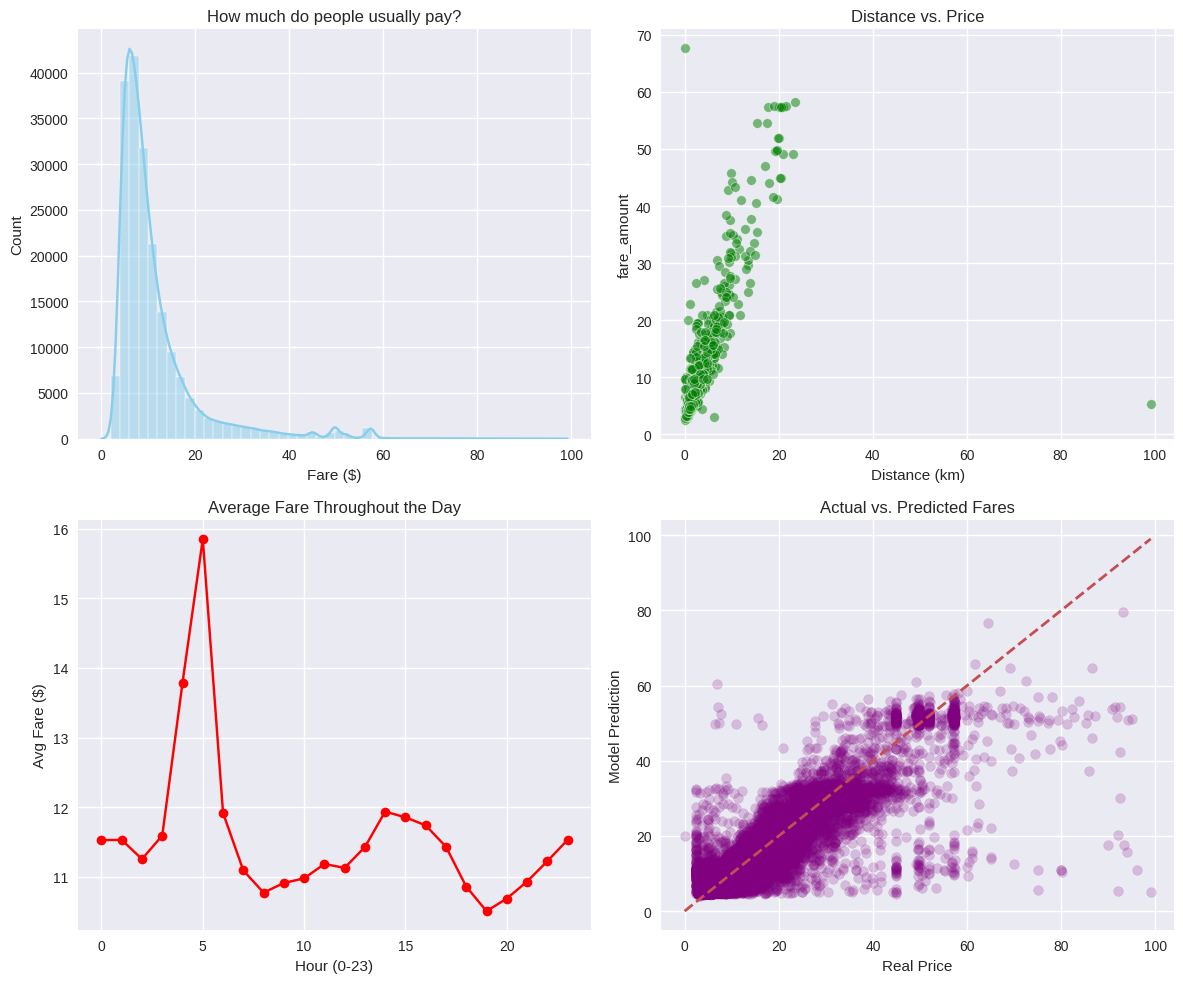

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style to make it look professional
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(12, 10))

# 1. Distribution of Fares
plt.subplot(2, 2, 1)
sns.histplot(df['fare_amount'], bins=50, kde=True, color='skyblue')
plt.title('How much do people usually pay?')
plt.xlabel('Fare ($)')

# 2. Distance vs Fare
plt.subplot(2, 2, 2)
# We use a sample so the plot doesn't get too crowded and slow
sns.scatterplot(x='distance_km', y='fare_amount', data=df.sample(1000), alpha=0.5, color='green')
plt.title('Distance vs. Price')
plt.xlabel('Distance (km)')

# 3. Fare by Hour
plt.subplot(2, 2, 3)
df.groupby('hour')['fare_amount'].mean().plot(kind='line', marker='o', color='red')
plt.title('Average Fare Throughout the Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Avg Fare ($)')

# 4. Actual vs Predicted (Accuracy Check)
plt.subplot(2, 2, 4)
plt.scatter(y_test, y_pred, alpha=0.2, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Fares')
plt.xlabel('Real Price')
plt.ylabel('Model Prediction')

plt.tight_layout()
plt.show() # <--- THIS is the line that makes them appear!